# Imports

In [23]:
import mne
import mne.io
import numpy as np
import pandas as pd

from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import ttest_ind

# Data Load

In [12]:
eeg_file_path_format = 'openneuro_data/sub-{number:03}/eeg/sub-{number:03}_task-eyesclosed_eeg.set'

rows = []

for n in range(1, 66):
    file_path = eeg_file_path_format.format(number=n)
    raw = mne.io.read_raw_eeglab(file_path, preload=True)
    data = raw.to_data_frame()
    data.drop('time', axis=1, inplace=True)
    data = pd.Series(data.to_numpy().flatten()).iloc[:19*500*60] # number of leads * sampling rate * one minute
    data = data.reset_index(drop=True)
    rows.append(data)

X = pd.DataFrame(rows)

C:\Users\Nathaniel Byrd\AppData\Local\Temp\ipykernel_78636\1272438242.py:7: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True)
C:\Users\Nathaniel Byrd\AppData\Local\Temp\ipykernel_78636\1272438242.py:7: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True)
C:\Users\Nathaniel Byrd\AppData\Local\Temp\ipykernel_78636\1272438242.py:7: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True)
C:\Users\Nathaniel Byrd\AppData\Local\Temp\ipykernel_78636\1272438242.py:7: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be caut

In [3]:
X.describe()

,0,1,2,3,4,5,6,7,8,9,...,28490,28491,28492,28493,28494,28495,28496,28497,28498,28499
0,-33.716686,-25.142326,-10.501626,-15.470965,-14.639780,-18.083931,-12.670144,-15.455706,-14.112548,-14.500907,...,84.186966,80.656410,80.066750,75.867516,82.771355,80.002563,84.764076,78.216400,82.228630,80.900940
1,-13.547649,-12.982911,-12.864223,-15.478166,-14.479111,-13.763200,-12.896243,-12.010491,-10.874237,-16.251282,...,7.027158,-1.294021,-3.387452,1.531427,2.273715,5.826613,8.252597,-2.182768,0.874269,-0.911403
2,-1.384971,0.310200,-3.326930,2.742624,0.656810,3.078944,2.110509,8.903687,2.517761,15.549582,...,-33.552906,-42.946068,-40.402092,-30.880066,-41.598820,-27.987234,-48.225449,-37.611465,-25.235281,-24.168118
3,4.723902,0.145953,-1.533589,-2.637750,-2.022448,-3.029307,-5.379206,3.803151,1.642603,-4.996177,...,-4.494199,-10.819843,-1.529887,-13.284366,-3.820531,-12.729028,-3.611506,-15.833203,-15.153379,-9.968896
4,-19.379652,-20.684259,-38.117813,-33.889000,-24.819490,-22.959326,-23.725227,-22.191916,-16.936806,-26.684614,...,-24.003325,-17.608561,-20.980371,-31.881996,-19.497616,-25.899683,-23.272934,-27.048422,-21.935608,-26.034338


In [3]:
labels_file_path = 'openneuro_data/participants.tsv'

Y = pd.read_csv(labels_file_path, sep='\t')
Y = Y['Group'].iloc[:65]
Y.head()

0    A
1    A
2    A
3    A
4    A
Name: Group, dtype: str

In [5]:
Y.describe()

count     65
unique     2
top        A
freq      36
Name: Group, dtype: object

# Task 1: Understanding the Raw EEG Signal

## Get P3 lead

In [27]:
# Choosing sub-001 for AD and sub-065 for HC
# P3 lead : index % 19 == 6
P3_lead_AD = X.iloc[0] # get sub-001
P3_lead_HC = X.iloc[64] # get sub-065

P3_lead_AD = P3_lead_AD[P3_lead_AD.index % 19 == 6] # keep only lead #6 (zero-indexed), which is P3
P3_lead_HC = P3_lead_HC[P3_lead_HC.index % 19 == 6]

P3_lead_AD.reset_index(inplace=True, drop=True)
P3_lead_HC.reset_index(inplace=True, drop=True)

P3_lead_AD

0       -12.670144
1       -11.895370
2       -11.468915
3       -11.322964
4       -11.326547
           ...    
29995    -6.689664
29996    -5.862956
29997    -4.438766
29998    -2.528227
29999    -0.350058
Name: 0, Length: 30000, dtype: float64

## Plotting

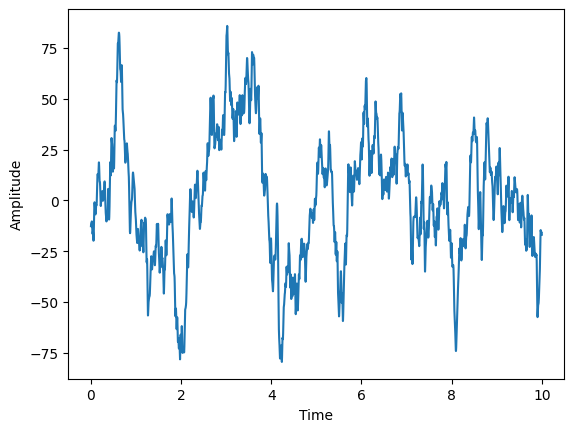

In [28]:
P3_lead_AD.index /= 500 # convert index to time
P3_lead_AD = P3_lead_AD.loc[:10] # take first 10 seconds

P3_lead_AD.plot()
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

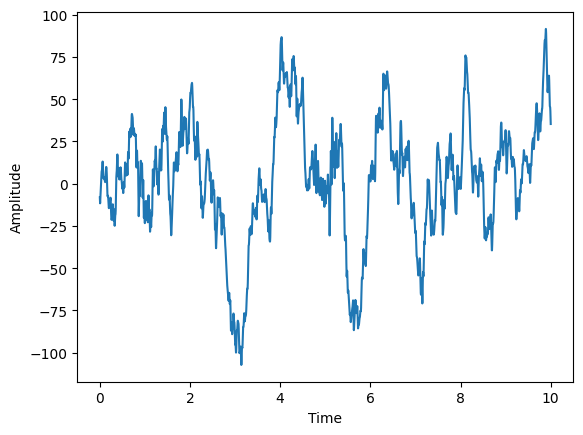

In [29]:
P3_lead_HC.index /= 500 # convert index to time
P3_lead_HC = P3_lead_HC.loc[:10] # take first 10 seconds

P3_lead_HC.plot()
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

# Task 2: Freq. Analysis and Band Power

In [8]:
fs = 500

delta_AD = []
delta_HC = []

theta_AD = []
theta_HC = []

alpha_AD = []
alpha_HC = []

beta_AD = []
beta_HC = []

for i in range(len(X)):

    subject = X.iloc[i]
    signal = subject[subject.index % 19 == 6].to_numpy()

    freqs, psd = welch(signal, fs=fs)

    delta_band = (freqs >= 1) & (freqs < 4)
    delta_power = np.mean(psd[delta_band])

    theta_band = (freqs >= 4) & (freqs < 8)
    theta_power = np.mean(psd[theta_band])

    alpha_band = (freqs >= 8) & (freqs < 13)
    alpha_power = np.mean(psd[alpha_band])

    beta_band = (freqs >= 13) & (freqs < 20)
    beta_power = np.mean(psd[beta_band])

    if Y.iloc[i] == "A":
        delta_AD.append(delta_power)
        theta_AD.append(theta_power)
        alpha_AD.append(alpha_power)
        beta_AD.append(beta_power)

    elif Y.iloc[i] == "C":
        delta_HC.append(delta_power)
        theta_HC.append(theta_power)
        alpha_HC.append(alpha_power)
        beta_HC.append(beta_power)

# Delta power for both groups
print("Average Delta Power (AD):", np.mean(delta_AD))
print("Average Delta Power (HC):", np.mean(delta_HC))
print("")
print("Average Theta Power (AD):", np.mean(theta_AD))
print("Average Theta Power (HC):", np.mean(theta_HC))
print("")
print("Average Alpha Power (AD):", np.mean(alpha_AD))
print("Average Alpha Power (HC):", np.mean(alpha_HC))
print("")
print("Average Beta Power (AD):", np.mean(beta_AD))
print("Average Beta Power (HC):", np.mean(beta_HC))

Average Delta Power (AD): 66.1570639673501
Average Delta Power (HC): 68.02446609031074

Average Theta Power (AD): 8.932710708267697
Average Theta Power (HC): 12.21328450278374

Average Alpha Power (AD): 3.4987355929898434
Average Alpha Power (HC): 7.447955579981789

Average Beta Power (AD): 1.1345762099068357
Average Beta Power (HC): 1.7750523009309753


# Task 3: Statistical Comparison Between Groups

## Calculation

In [15]:
# for some reason all the columns get interpreted as 'objects', which makes matplotlib tweak out so we'll enforce numeric types
rows = []

for i in range(len(X)):
    subject = X.iloc[i]
    signal = subject[subject.index % 19 == 6].to_numpy()
    freqs, psd = welch(signal, fs=fs)

    alpha_band = (freqs >= 8) & (freqs < 13)
    alpha_power = np.mean(psd[alpha_band])

    theta_band = (freqs >= 4) & (freqs < 8)
    theta_power = np.mean(psd[theta_band])

    entry = pd.Series([i, Y.iloc[i], alpha_power, theta_power], index=band_powers.columns)

    rows.append(entry)

band_powers = pd.DataFrame(rows)
band_powers

,Subject,Class,Alpha,Theta
0,0,A,1.988198,7.111964
1,1,A,4.203291,9.369548
2,2,A,4.480143,9.681611
3,3,A,1.946043,7.767252
4,4,A,2.523403,7.668369
...,...,...,...,...
60,60,C,2.491525,6.975489
61,61,C,8.190490,11.963348
62,62,C,3.434202,7.718948
63,63,C,27.718230,20.635588


## Plotting

### Healthy Control Group

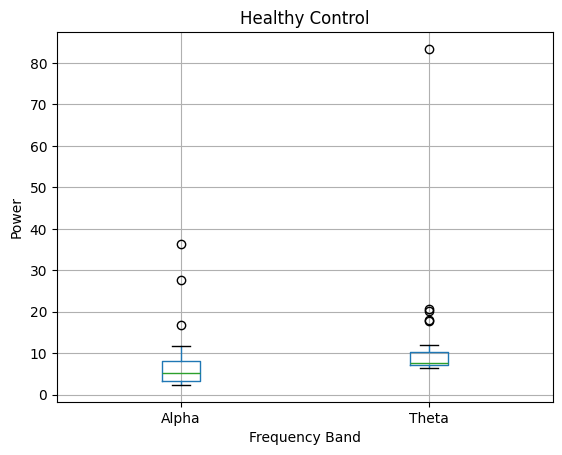

In [21]:
healthy = band_powers[band_powers['Class'] == 'C']

healthy[['Alpha', 'Theta']].boxplot()
plt.title('Healthy Control')
plt.xlabel('Frequency Band')
plt.ylabel('Power')
plt.show()


### Alzheimer's Group

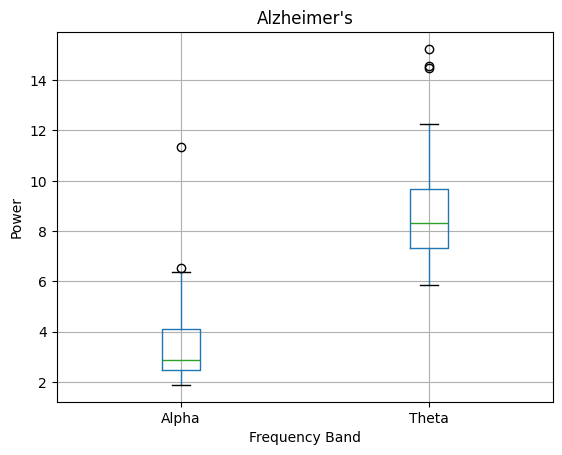

In [22]:
alzheimers = band_powers[band_powers['Class'] == 'A']

alzheimers[['Alpha', 'Theta']].boxplot()
plt.title('Alzheimer\'s')
plt.xlabel('Frequency Band')
plt.ylabel('Power')
plt.show()

## Statistical Tests

In [24]:
t_stat_alpha, p_value_alpha = ttest_ind(healthy['Alpha'], alzheimers['Alpha'])
t_stat_theta, p_value_theta = ttest_ind(healthy['Theta'], alzheimers['Theta'])

print(f'Alpha Band:\n\tT-stat: {t_stat_alpha}\n\tP-value: {p_value_alpha}\n')
print(f'Theta Band:\n\tT-stat: {t_stat_theta}\n\tP-value: {p_value_theta}')

Alpha Band:
	T-stat: 2.9853339466337503
	P-value: 0.004029528897206112

Theta Band:
	T-stat: 1.3582171127235267
	P-value: 0.17923899751755207
